# Spearman Correlation Analysis: Hormonal Signatures vs. Immune Cell Infiltration

Hormones do not act in isolation — they actively shape the immune landscape of tumors. 
Glucocorticoids suppress immune activation, androgens modulate T-cell function, and 
estrogens influence B-cell and NK-cell activity. Quantifying these relationships 
at the transcriptional level, across tumor types and tissue contexts, can reveal 
targetable axes in the tumor microenvironment (TME).

In this notebook, I compute **Spearman correlations** between:
- **Hormonal pathway activity** (ssGSEA enrichment scores from curated MSigDB/literature gene sets)
- **Immune cell abundance** (CIBERSORT absolute mode estimates)

 in both **Primary Tumor (TUM)** and **Normal Adjacent Tissue (NAT)** samples.

**Key methodological choices:**
- Spearman rank correlation: robust to outliers and non-normal distributions, 
  appropriate for enrichment scores and deconvolution estimates
- Minimum 10 samples per cell type required to compute a correlation — 
  below this threshold, results are unreliable and masked as NaN
- Samples filtered by TCGA barcode suffix to avoid mixing tissue types within a cohort
- Results saved as separate correlation and p-value matrices for flexible downstream use

This framework is fully generalizable: any pair of per-sample continuous scores 
(pathway activity, mutation burden, methylation, clinical variables) can be 
substituted into this correlation engine.

## 1. Imports

Standard scientific Python stack:
- **pandas / numpy**: data manipulation and numerical operations  
- **scipy.stats.spearmanr**: non-parametric rank correlation with p-values  
- **matplotlib / seaborn**: visualization (used in downstream plotting notebooks)

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Analysis Parameters

We define two key inputs upfront:

**Hormonal signatures** — seven gene sets capturing transcriptional responses to 
major endocrine signals (thyroid hormone, progesterone, aldosterone, androgens, 
estrogens, and glucocorticoids). These were scored per-sample via ssGSEA in the 
previous notebook.

**Tumor cohorts** — 12 TCGA cancer types selected for having sufficient sample 
size in both tumor and normal adjacent tissue compartments, spanning diverse 
tissue origins (urological, breast, colorectal, lung, liver, thyroid, endometrial).

Centralizing these parameters makes it trivial to extend the analysis to new 
hormones or cohorts.

In [6]:
# ── Analysis parameters ────────────────────────────────────────────────────
SIGNATURES = [
    "thyroid_GOBP_CELLULAR_RESPONSE_TO_THYROID_HORMONE_STIMULUS",
    "progesterone_GOBP_CELLULAR_RESPONSE_TO_PROGESTERONE_STIMULUS",
    "aldosterone_GOBP_RESPONSE_TO_ALDOSTERONE",
    "androgen_HALLMARK_ANDROGEN_RESPONSE",
    "estrogen_HALLMARK_ESTROGEN_RESPONSE_EARLY",
    "estrogen_HALLMARK_ESTROGEN_RESPONSE_LATE",
    "cortisol_glucocorticoid_GOBP_RESPONSE_TO_CORTISOL",
]

TUMORS = ['LUAD']#["BLCA", "BRCA", "COAD", "HNSC", "KIRC", "KIRP",
          #"LIHC", "LUAD", "LUSC", "PRAD", "THCA", "UCEC"]

SAMPLE_TYPES = [
    {"folder": "TumorSamples", "label": "TUM", "barcode_suffix": "-01A"},
    {"folder": "NATSamples",   "label": "NAT", "barcode_suffix": "-11A"},
]

MIN_SAMPLES = 10  # minimum non-zero samples to compute a valid correlation

## 3. Spearman Correlation: Hormonal Activity vs. Immune Infiltration

For each tumor type and tissue compartment (TUM / NAT), we:

1. Load CIBERSORT immune cell estimates and hormone ssGSEA scores
2. Merge the two data frames on sample ID (TCGA barcode)
3. Filter to the correct tissue type using TCGA barcode suffixes 
   (`-01A` for primary tumor, `-11A` for normal adjacent)
4. Compute Spearman correlation and p-value for every 
   (hormone signature × immune cell type) pair
5. Apply a minimum sample size filter (n ≥ 10) to ensure statistical reliability
6. Store results in structured correlation and p-value matrices

The output matrices have cell types as rows and 
`tumor.hormone.n_samples_tissuetype` as column labels — 
a format designed for direct heatmap visualization.

In [28]:
# ── Helper functions ───────────────────────────────────────────────────────

def load_deconv(tumor: str) -> pd.DataFrame:
    #Load CIBERSORT output and return a samples × cell_types DataFrame.
    path = f"Output/Deconvolution/TCGA-{tumor}_TumorSamples&NATSamples_No_outlier_TPM_CibersortAbsModeDeconv.tsv"
    df = pd.read_csv(path, sep="\t")
    # Fix TCGA barcodes: dots → dashes
    df.columns = ["cell_type"] + [c.replace(".", "-") for c in df.columns[1:]]
    # Transpose so rows = samples, columns = cell types
    df = df.set_index("cell_type").T
    df.index.name = "case_id"
    return df


def load_hormones(tumor: str) -> pd.DataFrame:
    #Load per-sample hormone ssGSEA enrichment scores.
    path = f"Output/ssGSEA/Output_ssGSEA_{tumor}_TumorSamples&NATSamples_No_outlier.tsv"
    horm_df=pd.read_csv(path, sep="\t")
    horm_df.index=[e.replace('.','-') for e in horm_df.index]
    return(horm_df)



def filter_by_barcode(df: pd.DataFrame, suffix: str) -> pd.DataFrame:
    #Keep only samples whose TCGA barcode ends with the expected suffix.
    mask = df.index.str.contains(
        f"{suffix}(?!-1)", regex=True, na=False
    )
    return df[mask].reset_index(drop=True)


def compute_correlations(
    merged: pd.DataFrame,
    hormone: str,
    cell_types: list,
    min_samples: int = MIN_SAMPLES,
) -> tuple[list, list]:
    
    #Compute Spearman correlation between one hormone signature and all cell types.
    #Returns (correlations, p-values), with NaN where sample size < min_samples.
    
    correlations, pvalues = [], []
    for cell in cell_types:
        valid = merged[cell].replace(0, np.nan).dropna()
        if len(valid) >= min_samples:
            idx = valid.index
            rho, pval = spearmanr(merged.loc[idx, hormone], merged.loc[idx, cell])
            correlations.append(rho)
            pvalues.append(pval)
        else:
            correlations.append(np.nan)
            pvalues.append(np.nan)
    return correlations, pvalues

In [29]:
# ── Main loop ──────────────────────────────────────────────────────────────
for tumor in TUMORS:
    print(f"\nProcessing: {tumor}")

    # Initialise result DataFrames with cell type index from first available file
    ref_deconv = load_deconv(tumor)
    cell_types  = list(ref_deconv.columns)

    df_corr = pd.DataFrame({"cell_type": cell_types})
    df_pval = pd.DataFrame({"cell_type": cell_types})

    for st in SAMPLE_TYPES:
        print(st)
        print(f"  → {st['label']}")

        deconv   = load_deconv(tumor)
        hormones = load_hormones(tumor)

        # Merge on sample ID, then filter to the correct tissue barcode
        merged_full = pd.merge(
            hormones, deconv,
            left_index=True, right_index=True
        )
        merged = filter_by_barcode(merged_full, st["barcode_suffix"])
        n_samples = len(merged)
        print(f"     {n_samples} samples after barcode filter")

        for hormone in SIGNATURES:
        
            col_label = f"{tumor}.{hormone}.{n_samples}_{st['label']}"
            corrs, pvals = compute_correlations(merged, hormone, cell_types)
            
            df_corr[col_label] = corrs
            df_pval[col_label] = pvals

    # ── Save results ──────────────────────────────────────────────────────────
    base_path = f"Output/correlation_matrices/{tumor}"
    df_corr.to_csv(
        f"{base_path}_corrSPEARMAN_hormonesVSimmune_cell_type_NAT&TumorSamples_atLeast10paz.tsv",
        sep="\t", index=False
    )
    df_pval.to_csv(
        f"{base_path}_p-valueSPEARMAN_hormonesVSimmune_cell_type_NAT&TumorSamples_atLeast10paz.tsv",
        sep="\t", index=False
    )
    print(f"  Saved correlation matrices for {tumor}")


Processing: LUAD
{'folder': 'TumorSamples', 'label': 'TUM', 'barcode_suffix': '-01A'}
  → TUM
     233 samples after barcode filter
{'folder': 'NATSamples', 'label': 'NAT', 'barcode_suffix': '-11A'}
  → NAT
     24 samples after barcode filter
  Saved correlation matrices for LUAD


## 4 Heatmap — correlation values between hormones and immune cells proportions

The heatmap below shows hormonal pathway activity correlated with immune cell types proportions

This visualization allows us to:
- Identify **immune-type-specific hormonal patterns** at a glance
- See whether pathway activation is globally higher or lower in tumor vs. normal


C:\Users\Chiara\AppData\Local\Temp\ipykernel_13768\3045148183.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


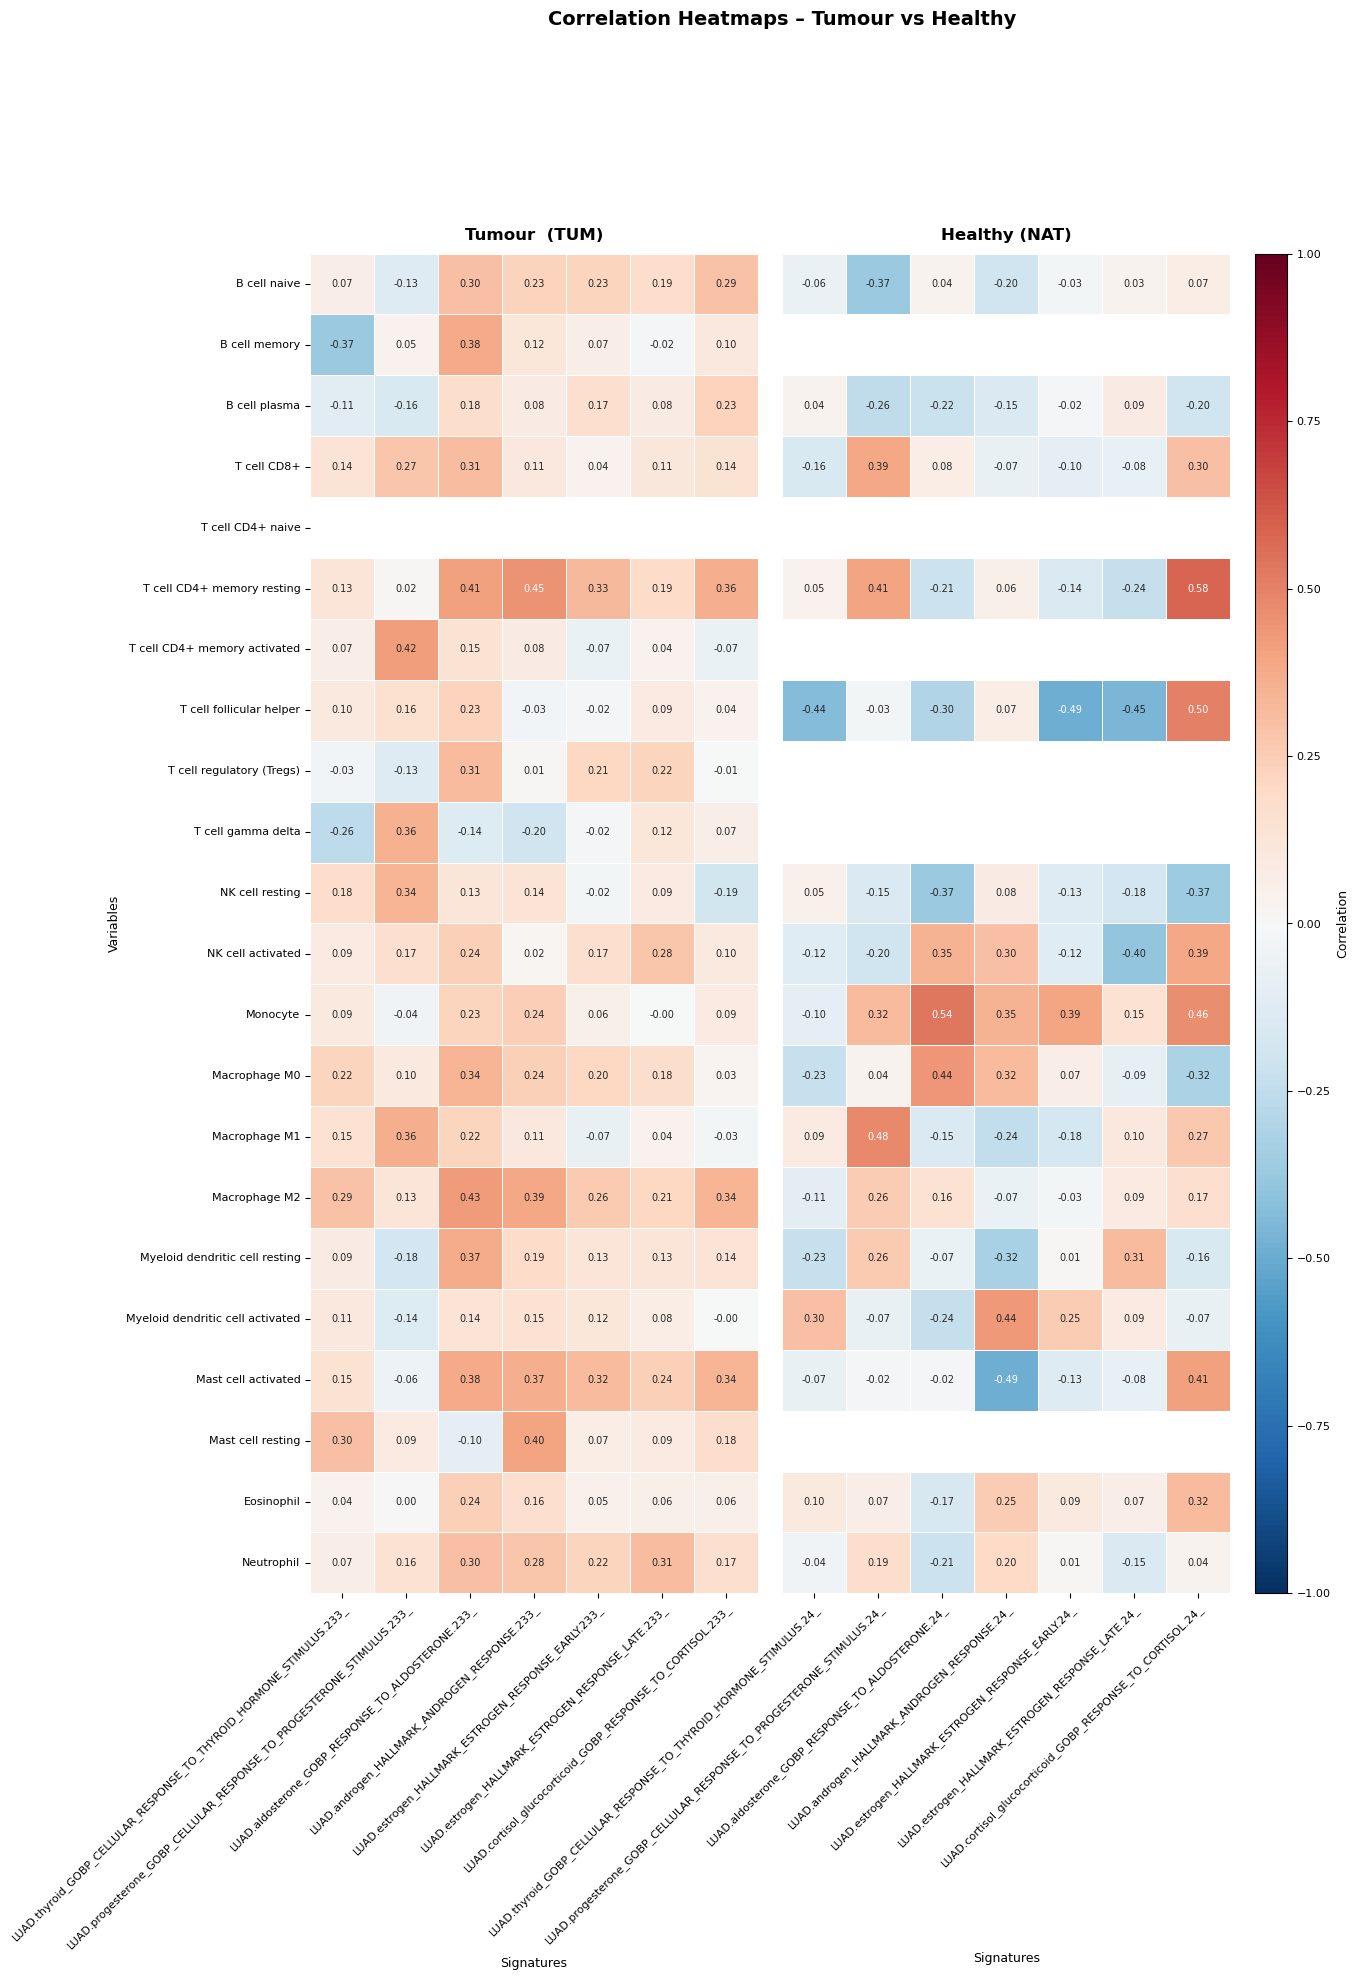

Figure saved to heatmap_correlation.png


In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

df=df_corr
# ─────────────────────────────────────────────

# ── Set the first column (variable names) as the index
df = df.set_index(df.columns[0])

# ── Split columns into tumour (TUM) and normal/healthy (NAT) subsets
df_tum = df[[c for c in df.columns if c.endswith("TUM")]]
df_nat = df[[c for c in df.columns if c.endswith("NAT")]]

# ── Clean column labels (remove suffix for a cleaner axis)
df_tum.columns = [c.replace("TUM", "") for c in df_tum.columns]
df_nat.columns = [c.replace("NAT", "") for c in df_nat.columns]

# ── Shared color scale anchored at [-1, 1] so both heatmaps are comparable
vmin, vmax = -1, 1
cmap = "RdBu_r"          # red = positive correlation, blue = negative

# ── Determine a common cell size so the figure scales with the data
n_rows = len(df_tum)
n_cols_tum = len(df_tum.columns)
n_cols_nat = len(df_nat.columns)
cell_size = 0.7           # inches per cell
cbar_width = 0.3          # inches for the colour-bar

fig_width  = (n_cols_tum + n_cols_nat) * cell_size + cbar_width + 2.5
fig_height = n_rows * cell_size + 2.0

# ── Create the figure: two heatmap axes + one axis for the shared colour bar
fig = plt.figure(figsize=(fig_width, fig_height))

# GridSpec: left heatmap | right heatmap | colour-bar
gs = fig.add_gridspec(
    1, 3,
    width_ratios=[n_cols_tum, n_cols_nat, 0.5],
    wspace=0.08,
)

ax_tum  = fig.add_subplot(gs[0, 0])
ax_nat  = fig.add_subplot(gs[0, 1])
ax_cbar = fig.add_subplot(gs[0, 2])

# ── Helper: draw one heatmap panel
def draw_heatmap(ax, data, title, show_yticklabels=True):
    sns.heatmap(
        data,
        ax=ax,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        linewidths=0.4,
        linecolor="white",
        annot=True,
        fmt=".2f",
        annot_kws={"size": 7},
        cbar=False,                   # colour bar drawn separately
        yticklabels=show_yticklabels,
    )
    ax.set_title(title, fontsize=12, fontweight="bold", pad=10)
    ax.set_xlabel("Signatures", fontsize=9)
    ax.set_ylabel("Variables" if show_yticklabels else "", fontsize=9)
    ax.set_xticklabels(
        ax.get_xticklabels(),
        rotation=45,
        ha="right",          # anchor the right end of the text to the tick
        rotation_mode="anchor",
        fontsize=8
    )
    ax.tick_params(axis="y", rotation=0,  labelsize=8)

# ── Draw the two panels
draw_heatmap(ax_tum, df_tum, "Tumour  (TUM)",  show_yticklabels=True)
draw_heatmap(ax_nat, df_nat, "Healthy (NAT)",  show_yticklabels=False)

# ── Shared colour bar
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
sm   = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=ax_cbar)
cbar.set_label("Correlation", fontsize=9)
cbar.ax.tick_params(labelsize=8)

# ── Overall title
fig.suptitle("Correlation Heatmaps – Tumour vs Healthy",
             fontsize=14, fontweight="bold", y=1.02)

plt.tight_layout()
plt.savefig("figures/immuneVShormones_heatmap_correlation.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved to heatmap_correlation.png")

## 5. Output & Next Steps

For each of the 12 tumor types, two matrices have been saved:
- `_corrSPEARMAN_...tsv` — Spearman ρ values
- `_p-valueSPEARMAN_...tsv` — associated p-values



The separation of TUM and NAT results within the same matrix enables direct 
visualization of how the tumor microenvironment differs from normal tissue 
in terms of hormone-immune relationships.

---
*Next: `04_predictive_modelling.ipynb` — Ridge Regression per immune cell type per tumor type, with cross-validation with SHAP values to identify which hormonal pathways drive each prediction*